In [4]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


import re
import string
import nltk
import os

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from textblob import TextBlob


from wordcloud import WordCloud


nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


pd.set_option('display.max_columns', None)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [5]:
import kagglehub

path = kagglehub.dataset_download(
   "jiashenliu/515k-hotel-reviews-data-in-europe"
)

# Load CSV
print("Dataset path:",path)
print(os.listdir(path))

Using Colab cache for faster access to the '515k-hotel-reviews-data-in-europe' dataset.
Dataset path: /kaggle/input/515k-hotel-reviews-data-in-europe
['Hotel_Reviews.csv']


In [10]:
import pandas as pd
import os

csv_file = os.path.join(path, "Hotel_Reviews.csv")

df = pd.read_csv(csv_file)



In [11]:
print(df.head())


                                       Hotel_Address  \
0   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...   
1   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...   
2   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...   
3   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...   
4   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...   

   Additional_Number_of_Scoring Review_Date  Average_Score   Hotel_Name  \
0                           194    8/3/2017            7.7  Hotel Arena   
1                           194    8/3/2017            7.7  Hotel Arena   
2                           194   7/31/2017            7.7  Hotel Arena   
3                           194   7/31/2017            7.7  Hotel Arena   
4                           194   7/24/2017            7.7  Hotel Arena   

  Reviewer_Nationality                                    Negative_Review  \
0              Russia    I am so angry that i made this post available...   
1             Ireland                                     

In [12]:
print(df.shape)

(515738, 17)


In [13]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515738 entries, 0 to 515737
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   Hotel_Address                               515738 non-null  object 
 1   Additional_Number_of_Scoring                515738 non-null  int64  
 2   Review_Date                                 515738 non-null  object 
 3   Average_Score                               515738 non-null  float64
 4   Hotel_Name                                  515738 non-null  object 
 5   Reviewer_Nationality                        515738 non-null  object 
 6   Negative_Review                             515738 non-null  object 
 7   Review_Total_Negative_Word_Counts           515738 non-null  int64  
 8   Total_Number_of_Reviews                     515738 non-null  int64  
 9   Positive_Review                             515738 non-null  object 
 

In [14]:
# Missing Values
df.isnull().sum()

,0
Hotel_Address,0
Additional_Number_of_Scoring,0
Review_Date,0
Average_Score,0
Hotel_Name,0
Reviewer_Nationality,0
Negative_Review,0
Review_Total_Negative_Word_Counts,0
Total_Number_of_Reviews,0
Positive_Review,0


In [15]:
# Statistical Summary
df.describe()

,Additional_Number_of_Scoring,Average_Score,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,lat,lng
count,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,512470.000000,512470.000000
mean,498.081836,8.397487,18.539450,2743.743944,17.776458,7.166001,8.395077,49.442439,2.823803
std,500.538467,0.548048,29.690831,2317.464868,21.804185,11.040228,1.637856,3.466325,4.579425
min,1.000000,5.200000,0.000000,43.000000,0.000000,1.000000,2.500000,41.328376,-0.369758
25%,169.000000,8.100000,2.000000,1161.000000,5.000000,1.000000,7.500000,48.214662,-0.143372
50%,341.000000,8.400000,9.000000,2134.000000,11.000000,3.000000,8.800000,51.499981,0.010607
75%,660.000000,8.800000,23.000000,3613.000000,22.000000,8.000000,9.600000,51.516288,4.834443
max,2682.000000,9.800000,408.000000,16670.000000,395.000000,355.000000,10.000000,52.400181,16.429233


In [16]:
df = df[['Hotel_Name',
         'Reviewer_Score',
         'Positive_Review',
         'Negative_Review']]

In [17]:
df['Review'] = df['Positive_Review'] + " " + df['Negative_Review']

In [18]:
df['Review'] = df['Review'].str.lower()

In [19]:
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

df['Review'] = df['Review'].apply(remove_punctuation)

In [20]:
def remove_numbers(text):
    return re.sub(r'\d+', '', text)

df['Review'] = df['Review'].apply(remove_numbers)

In [21]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['Review'] = df['Review'].apply(remove_stopwords)

In [22]:
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)

df['Review'] = df['Review'].apply(lemmatize_text)

In [23]:
df[['Review']].head()

,Review
0,park outside hotel beautiful angry made post a...
1,real complaint hotel great great location surr...
2,location good staff ok cute hotel breakfast ra...
3,great location nice surroundings bar restauran...
4,amazing location building romantic setting boo...


In [25]:
def get_sentiment(text):
    score = TextBlob(text).sentiment.polarity

    if score > 0:
        return "Positive"

    elif score < 0:
        return "Negative"

    else:
        return "Neutral"

df['Sentiment'] = df['Review'].apply(get_sentiment)

In [26]:
df[['Review','Sentiment']].head()

,Review,Sentiment
0,park outside hotel beautiful angry made post a...,Positive
1,real complaint hotel great great location surr...,Positive
2,location good staff ok cute hotel breakfast ra...,Positive
3,great location nice surroundings bar restauran...,Positive
4,amazing location building romantic setting boo...,Positive


In [27]:
df['Sentiment'].value_counts()

,count
Sentiment,
Positive,416885
Negative,73277
Neutral,25576


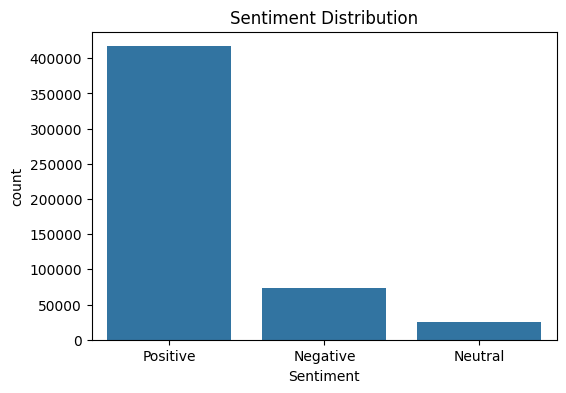

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(x='Sentiment',data=df)

plt.title("Sentiment Distribution")

plt.show()

In [29]:
issues = {
    "Room":["room","bed","bathroom"],
    "Staff":["staff","service","manager","reception"],
    "Cleanliness":["clean","dirty","dust"],
    "Food":["food","breakfast","restaurant"],
    "Amenities":["wifi","pool","gym","parking"]
}

In [30]:
for category, words in issues.items():

    df[category] = df['Review'].apply(
        lambda x: any(word in x for word in words)
    )

In [31]:
issue_counts = {}

for category in issues.keys():
    issue_counts[category] = df[category].sum()

issue_counts

{'Room': np.int64(305728),
 'Staff': np.int64(255193),
 'Cleanliness': np.int64(95785),
 'Food': np.int64(164872),
 'Amenities': np.int64(47679)}

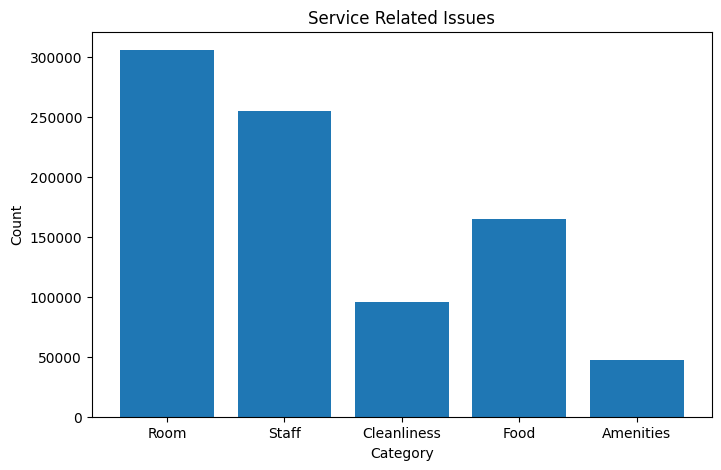

In [32]:
plt.figure(figsize=(8,5))

plt.bar(issue_counts.keys(),issue_counts.values())

plt.title("Service Related Issues")

plt.xlabel("Category")

plt.ylabel("Count")

plt.show()

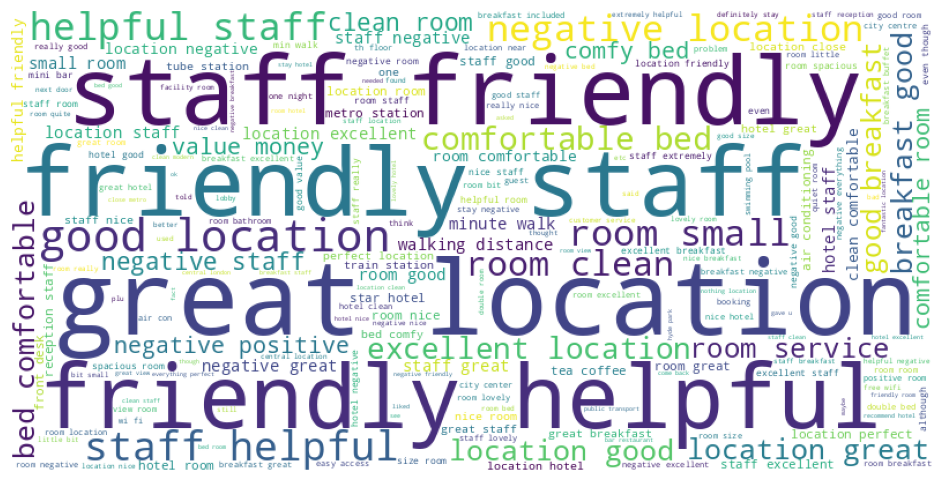

In [33]:
text = " ".join(df['Review'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

In [34]:
average_rating = df['Reviewer_Score'].mean()

print("Average Rating:",average_rating)

Average Rating: 8.395076569886262


In [35]:
sentiment_percentage = df['Sentiment'].value_counts(normalize=True)*100

print(sentiment_percentage)

Sentiment
Positive    80.832710
Negative    14.208183
Neutral      4.959107
Name: proportion, dtype: float64


In [38]:
# Create DataFrame of service issues
issue_df = pd.DataFrame(
    list(issue_counts.items()),
    columns=['Issue', 'Count']
)

# Sort by count
issue_df = issue_df.sort_values(by='Count', ascending=False)

# Display
print(issue_df)

         Issue   Count
0         Room  305728
1        Staff  255193
3         Food  164872
2  Cleanliness   95785
4    Amenities   47679


In [39]:
print("="*50)
print("HOTEL CUSTOMER SATISFACTION REPORT")
print("="*50)

print("\nAverage Reviewer Score")
print(round(average_rating,2))

print("\nSentiment Distribution")
print(df['Sentiment'].value_counts())

print("\nMost Reported Service Issues")
print(issue_df.sort_values(by='Count',ascending=False))

print("\nTotal Reviews")
print(len(df))

print("="*50)

HOTEL CUSTOMER SATISFACTION REPORT

Average Reviewer Score
8.4

Sentiment Distribution
Sentiment
Positive    416885
Negative     73277
Neutral      25576
Name: count, dtype: int64

Most Reported Service Issues
         Issue   Count
0         Room  305728
1        Staff  255193
3         Food  164872
2  Cleanliness   95785
4    Amenities   47679

Total Reviews
515738
